# METODE B: ViT Fine-tuning (TUNED VERSION)
## ECG Myocardial Infarction Classification

### 🔧 Perubahan dari Versi Sebelumnya:
| Aspek | Sebelum | Sesudah | Alasan |
|-------|---------|---------|--------|
| LR Backbone | 2e-5 | 1e-5 | Mencegah overfitting |
| LR Head | 1e-3 | 5e-4 | Lebih stabil |
| Weight Decay | 0.01 | 0.05 | Regularisasi lebih kuat |
| Dropout | Tidak ada | 0.3 | Mencegah overfitting |
| Label Smoothing | Tidak ada | 0.1 | Mencegah overconfidence |
| Data Augmentation | Tidak ada | Ada | Variasi data |
| Early Stopping | Patience=7 | Patience=4 | Stop lebih cepat |
| Epochs | 20 | 15 | Cukup, tidak perlu banyak |

## 1. Setup & Download Data

In [1]:
# Install dependencies
!pip install -q gdown transformers pillow tqdm scikit-learn seaborn
!apt-get update -qq && apt-get install -y -qq unrar

import gdown
import subprocess
import os

# Download dari Google Drive
FILE_ID = "18IjP8_q8V0-m1tjvVRhJmBADCv4Iri8_"
RAR_PATH = "/workspace/png_segments.rar"
EXTRACT_TO = "/workspace/data/"

# Skip jika data sudah ada
if os.path.exists("/workspace/data/png_segments/NORM"):
    print("✅ Data sudah ada, skip download")
else:
    print("📥 Downloading... (tunggu ~10-15 menit)")
    gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", RAR_PATH, quiet=True, fuzzy=True)

    if os.path.exists(RAR_PATH):
        size_gb = os.path.getsize(RAR_PATH) / (1024**3)
        print(f"✅ Download complete! Size: {size_gb:.2f} GB")
        
        print("\n📦 Extracting...")
        os.makedirs(EXTRACT_TO, exist_ok=True)
        result = subprocess.run(['unrar', 'x', '-o+', '-y', RAR_PATH, EXTRACT_TO], capture_output=True)
        
        if result.returncode == 0:
            print("✅ Extract complete!")
            os.remove(RAR_PATH)
            print("🗑️ RAR deleted")
        else:
            print(f"❌ Error: {result.stderr.decode()}")
    else:
        print("❌ Download failed")


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
debconf: delaying package configuration, since apt-utils is not installed
Selecting previously unselected package unrar.
(Reading database ... 24135 files and directories currently installed.)
Preparing to unpack .../unrar_1%3a6.1.5-1ubuntu0.1_amd64.deb ...
Unpacking unrar (1:6.1.5-1ubuntu0.1) ...
Setting up unrar (1:6.1.5-1ubuntu0.1) ...
update-alternatives: using /usr/bin/unrar-nonfree to provide /usr/bin/unrar (unrar) in auto mode
update-alternatives: warning: skip creation of /usr/share/man/man1/unrar.1.gz because associated file /usr/share/man/man1/unrar-nonfree.1.gz (of link group unrar) doesn't exist
✅ Data sudah ada, skip download


## 2. Import Libraries

In [2]:
import os, json, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from datetime import datetime
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torchvision import transforms
from transformers import ViTForImageClassification, ViTImageProcessor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Set seed untuk reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")
if torch.cuda.is_available(): 
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Device: cuda
   GPU: NVIDIA GeForce RTX 3090


## 3. Configuration (TUNED)

### 🔧 Penjelasan Hyperparameter:

```
LEARNING RATE:
- Terlalu besar → Model "lompat-lompat", tidak stabil
- Terlalu kecil → Belajar terlalu lambat
- Sweet spot: 1e-5 untuk backbone (sudah pre-trained)

WEIGHT DECAY:
- Regularisasi L2 untuk mencegah overfitting
- Membuat weight tidak terlalu besar
- 0.05 lebih kuat dari 0.01

DROPOUT:
- "Matikan" sebagian neuron secara random saat training
- Mencegah model terlalu bergantung pada neuron tertentu
- 0.3 = 30% neuron dimatikan

LABEL SMOOTHING:
- Ubah label dari [1, 0, 0, 0, 0] → [0.92, 0.02, 0.02, 0.02, 0.02]
- Mencegah model terlalu "percaya diri"
- 0.1 = 10% smoothing
```

In [3]:
# === CONFIGURATION (TUNED) ===
PNG_SEGMENTS_DIR = "/workspace/data/png_segments"
OUTPUT_DIR = "/workspace/output_method_b_tuned"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_NAME = "google/vit-base-patch16-224"
TARGET_CLASSES = ['NORM', 'AMI', 'ASMI', 'ILMI', 'IMI']
NUM_CLASSES = len(TARGET_CLASSES)
CLASS_TO_IDX = {c:i for i,c in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS = {i:c for c,i in CLASS_TO_IDX.items()}

# ========== TUNED HYPERPARAMETERS ==========
BATCH_SIZE = 32
NUM_EPOCHS = 15          # Dikurangi dari 20
PATIENCE = 4             # Dikurangi dari 7 (early stop lebih cepat)

LR_BACKBONE = 1e-5       # Dikurangi dari 2e-5 (lebih kecil = lebih stabil)
LR_HEAD = 5e-4           # Dikurangi dari 1e-3
WEIGHT_DECAY = 0.05      # Dinaikkan dari 0.01 (regularisasi lebih kuat)
WARMUP_EPOCHS = 2

DROPOUT_RATE = 0.3       # BARU: Dropout untuk mencegah overfitting
LABEL_SMOOTHING = 0.1    # BARU: Label smoothing

USE_AMP = True
# ============================================

print("="*60)
print("🔧 TUNED HYPERPARAMETERS")
print("="*60)
print(f"   Batch Size:      {BATCH_SIZE}")
print(f"   Epochs:          {NUM_EPOCHS}")
print(f"   Early Stop:      Patience={PATIENCE}")
print(f"   LR Backbone:     {LR_BACKBONE}")
print(f"   LR Head:         {LR_HEAD}")
print(f"   Weight Decay:    {WEIGHT_DECAY}")
print(f"   Dropout:         {DROPOUT_RATE}")
print(f"   Label Smoothing: {LABEL_SMOOTHING}")
print("="*60)

🔧 TUNED HYPERPARAMETERS
   Batch Size:      32
   Epochs:          15
   Early Stop:      Patience=4
   LR Backbone:     1e-05
   LR Head:         0.0005
   Weight Decay:    0.05
   Dropout:         0.3
   Label Smoothing: 0.1


## 4. Collect & Split Data

In [4]:
# === COLLECT DATA (REAL + SYNTHETIC) ===
data = []

# 1. Load data ASLI
for c in TARGET_CLASSES:
    cd = os.path.join(PNG_SEGMENTS_DIR, c)
    if not os.path.exists(cd): continue
    for ecg in tqdm(os.listdir(cd), desc=c):
        ep = os.path.join(cd, ecg)
        if os.path.isdir(ep):
            for f in os.listdir(ep):
                if f.endswith('.png'):
                    data.append({
                        'image_path': os.path.join(ep, f),
                        'label': c,
                        'label_idx': CLASS_TO_IDX[c],
                        'ecg_id': ecg,
                        'source': 'real'  # ← Tandai sebagai real
                    })

print(f"\n✅ Real data: {len(data):,} segments")

# 2. Load data SINTETIS AMI
SYNTH_DIR = "/workspace/ecg_gan_ami_v2/synthetic_png/AMI"  # ← sesuaikan path
synth_count = 0

if os.path.exists(SYNTH_DIR):
    for ecg_folder in sorted(os.listdir(SYNTH_DIR)):
        ep = os.path.join(SYNTH_DIR, ecg_folder)
        if os.path.isdir(ep):
            for f in sorted(os.listdir(ep)):
                if f.endswith('.png'):
                    data.append({
                        'image_path': os.path.join(ep, f),
                        'label': 'AMI',
                        'label_idx': CLASS_TO_IDX['AMI'],
                        'ecg_id': ecg_folder,
                        'source': 'synthetic'  # ← Tandai sebagai sintetis
                    })
                    synth_count += 1
    print(f"✅ Synthetic AMI: {synth_count:,} segments added")
else:
    print(f"⚠️  Synthetic dir not found: {SYNTH_DIR}")

df = pd.DataFrame(data)
print(f"\n✅ TOTAL: {len(df):,} segments from {df['ecg_id'].nunique():,} ECGs")

# Show class distribution (real vs synthetic)
print("\n📊 Class Distribution:")
for c in TARGET_CLASSES:
    real_count = len(df[(df['label'] == c) & (df['source'] == 'real')])
    synth_count_c = len(df[(df['label'] == c) & (df['source'] == 'synthetic')])
    total = real_count + synth_count_c
    pct = total / len(df) * 100
    synth_str = f" + {synth_count_c} synthetic" if synth_count_c > 0 else ""
    print(f"   {c}: {real_count:,} real{synth_str} = {total:,} ({pct:.1f}%)")


IMI: 100%|██████████| 1517/1517 [00:00<00:00, 28510.82it/s]



✅ Real data: 131,580 segments
✅ Synthetic AMI: 1,000 segments added

✅ TOTAL: 132,580 segments from 13,258 ECGs

📊 Class Distribution:
   NORM: 94,380 real = 94,380 (71.2%)
   AMI: 1,790 real + 1000 synthetic = 2,790 (2.1%)
   ASMI: 16,790 real = 16,790 (12.7%)
   ILMI: 3,450 real = 3,450 (2.6%)
   IMI: 15,170 real = 15,170 (11.4%)


In [5]:
# === PATIENT-WISE SPLIT ===
# Penting: Split berdasarkan PASIEN, bukan gambar
# Supaya gambar dari pasien yang sama tidak ada di train DAN test
# ⚠️ Data sintetis HANYA masuk ke TRAINING set!

# Split hanya berdasarkan data REAL
real_df = df[df['source'] == 'real'].copy()
ecg_labels = real_df.groupby('ecg_id')['label'].first().reset_index()
train_val, test_ecg = train_test_split(ecg_labels, test_size=0.2, stratify=ecg_labels['label'], random_state=SEED)
train_ecg, val_ecg = train_test_split(train_val, test_size=0.125, stratify=train_val['label'], random_state=SEED)

# Assign split untuk data real
df['split'] = 'train'  # default
df.loc[df['ecg_id'].isin(val_ecg['ecg_id']), 'split'] = 'val'
df.loc[df['ecg_id'].isin(test_ecg['ecg_id']), 'split'] = 'test'

# ⚠️ PENTING: Data sintetis HANYA di training set!
df.loc[df['source'] == 'synthetic', 'split'] = 'train'

train_df = df[df['split']=='train'].reset_index(drop=True)
val_df = df[df['split']=='val'].reset_index(drop=True)
test_df = df[df['split']=='test'].reset_index(drop=True)

print(f"📊 Data Split:")
print(f"   Train: {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)")
print(f"      ├── Real:      {len(train_df[train_df['source']=='real']):,}")
print(f"      └── Synthetic: {len(train_df[train_df['source']=='synthetic']):,}")
print(f"   Val:   {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%) — real only")
print(f"   Test:  {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%) — real only")

# Verifikasi: TIDAK ADA data sintetis di val/test
assert len(val_df[val_df['source']=='synthetic']) == 0, "❌ Synthetic data in validation!"
assert len(test_df[test_df['source']=='synthetic']) == 0, "❌ Synthetic data in test!"
print(f"\n✅ Verified: NO synthetic data in val/test sets")


📊 Data Split:
   Train: 93,100 (70.2%)
      ├── Real:      92,100
      └── Synthetic: 1,000
   Val:   13,160 (9.9%) — real only
   Test:  26,320 (19.9%) — real only

✅ Verified: NO synthetic data in val/test sets


## 5. Dataset dengan Data Augmentation

### 🔧 Penjelasan Data Augmentation:

```
MASALAH:
- Data terbatas → Model menghafal
- Model tidak bisa generalisasi

SOLUSI - DATA AUGMENTATION:
- Buat "variasi" dari gambar yang sama
- Model belajar dari berbagai kondisi

AUGMENTASI UNTUK ECG:
1. Horizontal Flip (30%): Membalik gambar
2. Rotation (±5°): Rotasi sedikit
3. Color Jitter: Variasi brightness/contrast
4. Random Affine: Geser sedikit

CATATAN: Augmentasi HANYA untuk training, TIDAK untuk validation/test
```

In [6]:
# === DATA AUGMENTATION ===

# Augmentasi untuk TRAINING (variasi data)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),           # Flip horizontal 30%
    transforms.RandomRotation(5),                      # Rotasi ±5 derajat
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # Variasi warna
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),  # Geser sedikit
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# TANPA augmentasi untuk VALIDATION dan TEST
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

print("✅ Data Augmentation configured:")
print("   Train: Flip, Rotation, ColorJitter, Affine")
print("   Val/Test: No augmentation (clean evaluation)")

✅ Data Augmentation configured:
   Train: Flip, Rotation, ColorJitter, Affine
   Val/Test: No augmentation (clean evaluation)


In [7]:
# === DATASET CLASS ===
class ECGDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
        
        label = torch.tensor(row['label_idx'], dtype=torch.long)
        return {'pixel_values': img, 'labels': label}

# Create datasets
train_dataset = ECGDataset(train_df, transform=train_transform)
val_dataset = ECGDataset(val_df, transform=val_test_transform)
test_dataset = ECGDataset(test_df, transform=val_test_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         num_workers=4, pin_memory=True)

print(f"✅ DataLoaders created:")
print(f"   Train: {len(train_loader)} batches")
print(f"   Val:   {len(val_loader)} batches")
print(f"   Test:  {len(test_loader)} batches")

✅ DataLoaders created:
   Train: 2909 batches
   Val:   412 batches
   Test:  823 batches


## 6. Model dengan Custom Classifier (Dropout Added)

### 🔧 Penjelasan Dropout:

```
TANPA DROPOUT:
Input → [N1] → [N2] → [N3] → [N4] → Output
         ↓      ↓      ↓      ↓
      Semua neuron aktif = Overfitting!

DENGAN DROPOUT (30%):
Input → [N1] → [X ] → [N3] → [X ] → Output
         ↓      ↓      ↓      ↓
      N2 & N4 dimatikan random = Lebih robust!

EFEK:
- Model tidak bergantung pada neuron tertentu
- Lebih bisa generalisasi ke data baru
- Mengurangi overfitting
```

In [8]:
# === LOAD MODEL ===
model = ViTForImageClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=NUM_CLASSES, 
    id2label=IDX_TO_CLASS, 
    label2id=CLASS_TO_IDX, 
    ignore_mismatched_sizes=True
)

# === CUSTOM CLASSIFIER DENGAN DROPOUT ===
# Ganti classifier default dengan yang ada dropout
model.classifier = nn.Sequential(
    nn.Dropout(DROPOUT_RATE),           # Dropout pertama
    nn.Linear(768, 256),                # Hidden layer
    nn.ReLU(),                          # Aktivasi
    nn.Dropout(DROPOUT_RATE * 0.5),     # Dropout kedua (lebih kecil)
    nn.Linear(256, NUM_CLASSES)         # Output layer
)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Model loaded with custom classifier:")
print(f"   Total params:     {total_params:,}")
print(f"   Trainable params: {trainable_params:,}")
print(f"\n📋 Custom Classifier Architecture:")
print(model.classifier)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Model loaded with custom classifier:
   Total params:     85,996,805
   Trainable params: 85,996,805

📋 Custom Classifier Architecture:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=768, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.15, inplace=False)
  (4): Linear(in_features=256, out_features=5, bias=True)
)


## 7. Training Setup (TUNED)

### 🔧 Penjelasan Label Smoothing:

```
TANPA LABEL SMOOTHING:
Target: [1, 0, 0, 0, 0]  ← "100% yakin ini NORM"
Model belajar: "Harus 100% yakin!"
Masalah: Overconfident, tidak bisa handle uncertainty

DENGAN LABEL SMOOTHING (0.1):
Target: [0.92, 0.02, 0.02, 0.02, 0.02]  ← "92% yakin NORM, sisanya mungkin"
Model belajar: "Boleh sedikit tidak yakin"
Efek: Lebih robust, generalisasi lebih baik
```

In [9]:
# === CLASS WEIGHTS ===
# Untuk handle class imbalance
class_counts = train_df['label'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("📊 Class Weights (untuk handle imbalance):")
for c, w in zip(TARGET_CLASSES, class_weights):
    print(f"   {c}: {w:.4f}")

# === LOSS FUNCTION DENGAN LABEL SMOOTHING ===
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING  # BARU: Label smoothing
)

print(f"\n✅ Loss: CrossEntropyLoss with label_smoothing={LABEL_SMOOTHING}")

📊 Class Weights (untuk handle imbalance):
   NORM: 2.1122
   AMI: 0.4045
   ASMI: 1.9639
   ILMI: 0.4475
   IMI: 0.0719

✅ Loss: CrossEntropyLoss with label_smoothing=0.1


In [10]:
# === OPTIMIZER DENGAN DIFFERENTIAL LEARNING RATE ===
# Backbone: LR kecil (sudah pre-trained)
# Classifier: LR lebih besar (baru, perlu belajar lebih banyak)

backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]
classifier_params = [p for n, p in model.named_parameters() if 'classifier' in n]

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': LR_BACKBONE},
    {'params': classifier_params, 'lr': LR_HEAD}
], weight_decay=WEIGHT_DECAY)

print(f"✅ Optimizer: AdamW")
print(f"   Backbone LR:   {LR_BACKBONE}")
print(f"   Classifier LR: {LR_HEAD}")
print(f"   Weight Decay:  {WEIGHT_DECAY}")

✅ Optimizer: AdamW
   Backbone LR:   1e-05
   Classifier LR: 0.0005
   Weight Decay:  0.05


In [11]:
# === LEARNING RATE SCHEDULER ===
# Warmup: Mulai dari LR kecil, naik pelan-pelan
# Cosine decay: Setelah warmup, turun perlahan

total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = len(train_loader) * WARMUP_EPOCHS

def lr_lambda(current_step):
    if current_step < warmup_steps:
        # Warmup: Linear increase
        return float(current_step) / float(max(1, warmup_steps))
    else:
        # Cosine decay
        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress)))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = GradScaler()

print(f"✅ Scheduler: Warmup ({WARMUP_EPOCHS} epochs) + Cosine Decay")
print(f"   Total steps:  {total_steps}")
print(f"   Warmup steps: {warmup_steps}")

✅ Scheduler: Warmup (2 epochs) + Cosine Decay
   Total steps:  43635
   Warmup steps: 5818


## 8. Training Functions

In [12]:
def train_epoch(model, loader, criterion, optimizer, scheduler, scaler, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    for batch in tqdm(loader, desc="Train", leave=False):
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            outputs = model(pixel_values=pixel_values)
            loss = criterion(outputs.logits, labels)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        
        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return avg_loss, accuracy, f1

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    
    for batch in tqdm(loader, desc="Eval", leave=False):
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(pixel_values=pixel_values)
        loss = criterion(outputs.logits, labels)
        
        total_loss += loss.item()
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        preds = outputs.logits.argmax(dim=1).cpu().numpy()
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return avg_loss, accuracy, f1, np.array(all_labels), np.array(all_preds), np.array(all_probs)

print("✅ Training functions defined")

✅ Training functions defined


## 9. Training Loop

In [13]:
# === TRAINING LOOP ===
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []
}

best_val_f1 = 0
best_val_loss = float('inf')
best_epoch = 0
patience_counter = 0

print("="*90)
print("🚀 TRAINING - METODE B (ViT Fine-tuning) - TUNED VERSION")
print("="*90)
print(f"{'Ep':^4}|{'Tr Loss':^10}|{'Tr Acc':^9}|{'Tr F1':^8}|{'Val Loss':^10}|{'Val Acc':^9}|{'Val F1':^8}|{'GAP':^6}|{'LR':^10}")
print("-"*90)

train_start_time = datetime.now()

for epoch in range(NUM_EPOCHS):
    # Training
    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, scheduler, scaler, device
    )
    
    # Validation
    val_loss, val_acc, val_f1, _, _, _ = evaluate(model, val_loader, criterion, device)
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Calculate GAP (Train Acc - Val Acc)
    gap = (train_acc - val_acc) * 100
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)
    
    # Check for best model (based on val_loss untuk menghindari overfitting)
    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        patience_counter = 0
        
        # Save best model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_f1': val_f1,
            'val_acc': val_acc
        }, os.path.join(OUTPUT_DIR, 'best_model.pth'))
    else:
        patience_counter += 1
    
    # Print progress
    gap_color = "⚠️" if gap > 5 else "✅"
    best_marker = " 🏆" if is_best else ""
    print(f"{epoch+1:^4}|{train_loss:^10.4f}|{train_acc:^9.4f}|{train_f1:^8.4f}|{val_loss:^10.4f}|{val_acc:^9.4f}|{val_f1:^8.4f}|{gap:^5.1f}%|{current_lr:^10.2e}{best_marker}")
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\n⚠️ Early stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs)")
        break

train_time = datetime.now() - train_start_time
print("-"*90)
print(f"🏆 Best: Epoch {best_epoch}, Val Loss: {best_val_loss:.4f}, Val F1: {best_val_f1:.4f}")
print(f"⏱️ Training time: {train_time}")

🚀 TRAINING - METODE B (ViT Fine-tuning) - TUNED VERSION
 Ep | Tr Loss  | Tr Acc  | Tr F1  | Val Loss | Val Acc | Val F1 | GAP  |    LR    
------------------------------------------------------------------------------------------


 1  |  0.4263  | 0.7618  | 0.6941 |  1.1285  | 0.8124  | 0.7472 |-5.1 %| 5.00e-06  🏆


 2  |  0.3132  | 0.8089  | 0.7476 |  1.0558  | 0.8198  | 0.7555 |-1.1 %| 1.00e-05  🏆


 3  |  0.2873  | 0.8224  | 0.7660 |  0.9694  | 0.8222  | 0.7672 | 0.0 %| 9.85e-06  🏆


 4  |  0.2731  | 0.8312  | 0.7791 |  1.0022  | 0.8381  | 0.7876 |-0.7 %| 9.43e-06 


...

 11 |  0.2293  | 0.8696  | 0.8366 |  0.8804  | 0.8564  | 0.8212 | 1.3 %| 2.16e-06 


 12 |  0.2262  | 0.8717  | 0.8383 |  0.8754  | 0.8625  | 0.8326 | 0.9 %| 1.26e-06 


 13 |  0.2233  | 0.8775  | 0.8484 |  0.8674  | 0.8627  | 0.8348 | 1.5 %| 5.73e-07  🏆


 14 |  0.2216  | 0.8794  | 0.8510 |  0.8777  | 0.8617  | 0.8321 | 1.8 %| 1.45e-07 


 15 |  0.2204  | 0.8788  | 0.8498 |  0.8787  | 0.8606  | 0.8300 | 1.8 %| 0.00e+00 
------------------------------------------------------------------------------------------
🏆 Best: Epoch 13, Val Loss: 0.8674, Val F1: 0.8348
⏱️ Training time: 1:18:56.430099


## 10. Training Curves Analysis

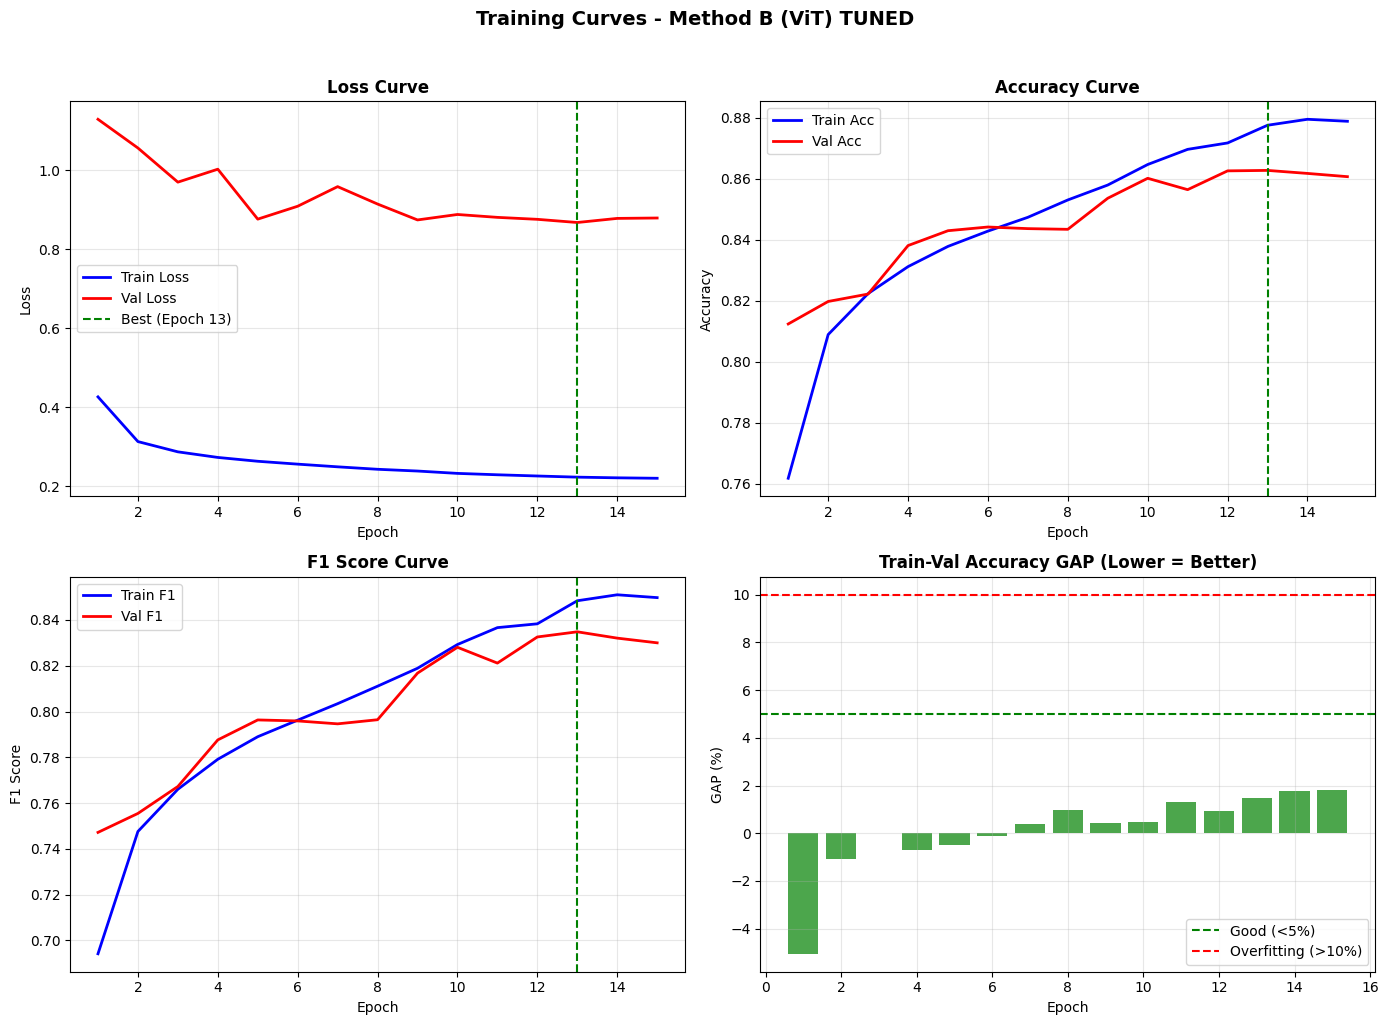

✅ Saved: training_curves.png


In [14]:
# === TRAINING CURVES ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
ax1 = axes[0, 0]
ax1.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
ax1.axvline(best_epoch, color='g', linestyle='--', label=f'Best (Epoch {best_epoch})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy
ax2 = axes[0, 1]
ax2.plot(epochs_range, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
ax2.plot(epochs_range, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
ax2.axvline(best_epoch, color='g', linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curve', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# F1 Score
ax3 = axes[1, 0]
ax3.plot(epochs_range, history['train_f1'], 'b-', label='Train F1', linewidth=2)
ax3.plot(epochs_range, history['val_f1'], 'r-', label='Val F1', linewidth=2)
ax3.axvline(best_epoch, color='g', linestyle='--')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('F1 Score')
ax3.set_title('F1 Score Curve', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# GAP (Train - Val Accuracy)
ax4 = axes[1, 1]
gap_values = [(t - v) * 100 for t, v in zip(history['train_acc'], history['val_acc'])]
colors = ['green' if g <= 5 else 'orange' if g <= 10 else 'red' for g in gap_values]
ax4.bar(epochs_range, gap_values, color=colors, alpha=0.7)
ax4.axhline(5, color='green', linestyle='--', label='Good (<5%)')
ax4.axhline(10, color='red', linestyle='--', label='Overfitting (>10%)')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('GAP (%)')
ax4.set_title('Train-Val Accuracy GAP (Lower = Better)', fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

plt.suptitle('Training Curves - Method B (ViT) TUNED', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: training_curves.png")

## 11. Load Best Model & Evaluate on Test Set

In [22]:
# === LOAD BEST MODEL ===
checkpoint = torch.load(os.path.join(OUTPUT_DIR, 'best_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"   Val Loss: {checkpoint['val_loss']:.4f}")
print(f"   Val Acc:  {checkpoint['val_acc']:.4f}")
print(f"   Val F1:   {checkpoint['val_f1']:.4f}")

✅ Loaded best model from epoch 13
   Val Loss: 0.8674
   Val Acc:  0.8627
   Val F1:   0.8348


In [16]:
# === FINAL EVALUATION ON TEST SET ===
print("\n📊 Evaluating on TEST SET...")
test_loss, test_acc, test_f1, y_true, y_pred, y_probs = evaluate(
    model, test_loader, criterion, device
)

# Calculate additional metrics
precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
f1_macro = f1_score(y_true, y_pred, average='macro')
precision_per_class = precision_score(y_true, y_pred, average=None)
recall_per_class = recall_score(y_true, y_pred, average=None)
f1_per_class = f1_score(y_true, y_pred, average=None)

print(f"\n{'='*50}")
print(f"🎯 TEST SET RESULTS")
print(f"{'='*50}")
print(f"   Accuracy:      {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   F1 Weighted:   {test_f1:.4f}")
print(f"   F1 Macro:      {f1_macro:.4f}")
print(f"   Precision:     {precision_weighted:.4f}")
print(f"   Recall:        {recall_weighted:.4f}")


📊 Evaluating on TEST SET...



🎯 TEST SET RESULTS
   Accuracy:      0.8560 (85.60%)
   F1 Weighted:   0.8263
   F1 Macro:      0.5250
   Precision:     0.8627
   Recall:        0.8560


In [17]:
# === PER-CLASS METRICS ===
print(f"\n📊 Per-Class Metrics:")
metrics_df = pd.DataFrame({
    'Class': TARGET_CLASSES,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1': f1_per_class,
    'Support': [sum(y_true == i) for i in range(NUM_CLASSES)]
}).round(4)
print(metrics_df.to_string(index=False))

metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'per_class_metrics.csv'), index=False)
print("\n✅ Saved: per_class_metrics.csv")

# Classification Report
report = classification_report(y_true, y_pred, target_names=TARGET_CLASSES, digits=4)
print(f"\n📊 Classification Report:")
print(report)

with open(os.path.join(OUTPUT_DIR, 'classification_report.txt'), 'w') as f:
    f.write(report)
print("✅ Saved: classification_report.txt")


📊 Per-Class Metrics:
Class  Precision  Recall     F1  Support
 NORM     0.9056  0.9915 0.9466    18880
  AMI     0.2193  0.0694 0.1055      360
 ASMI     0.6937  0.8464 0.7625     3360
 ILMI     0.4554  0.5623 0.5032      690
  IMI     0.9520  0.1832 0.3072     3030

✅ Saved: per_class_metrics.csv

📊 Classification Report:
              precision    recall  f1-score   support

        NORM     0.9056    0.9915    0.9466     18880
         AMI     0.2193    0.0694    0.1055       360
        ASMI     0.6937    0.8464    0.7625      3360
        ILMI     0.4554    0.5623    0.5032       690
         IMI     0.9520    0.1832    0.3072      3030

    accuracy                         0.8560     26320
   macro avg     0.6452    0.5306    0.5250     26320
weighted avg     0.8627    0.8560    0.8263     26320

✅ Saved: classification_report.txt


## 12. Confusion Matrix

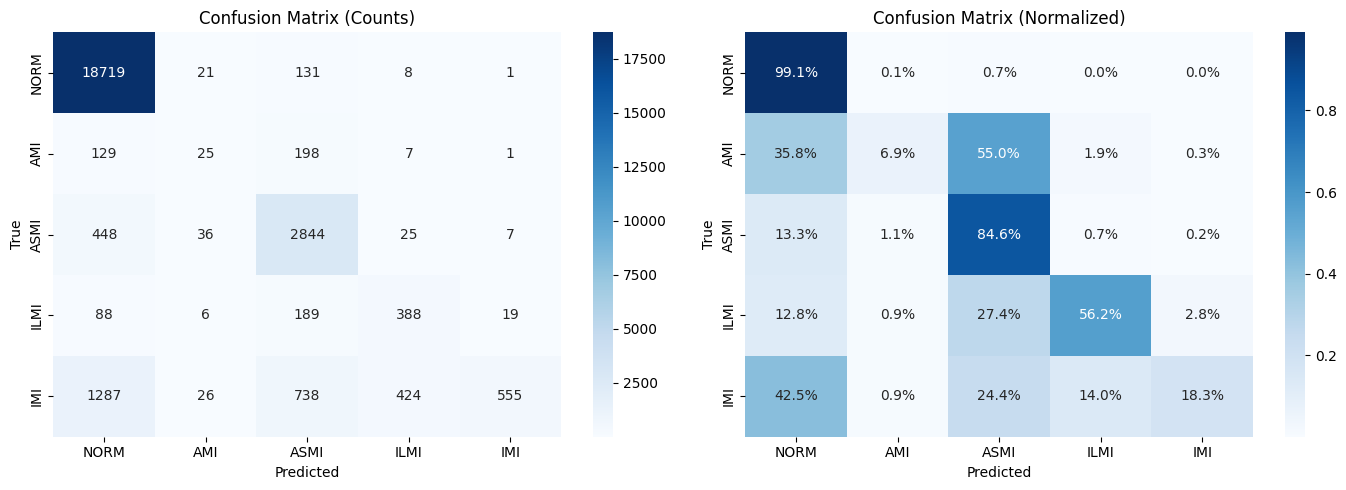

✅ Saved: confusion_matrix.png


In [18]:
# === CONFUSION MATRIX ===
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (Counts)')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Blues', 
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png")

## 13. ROC Curves

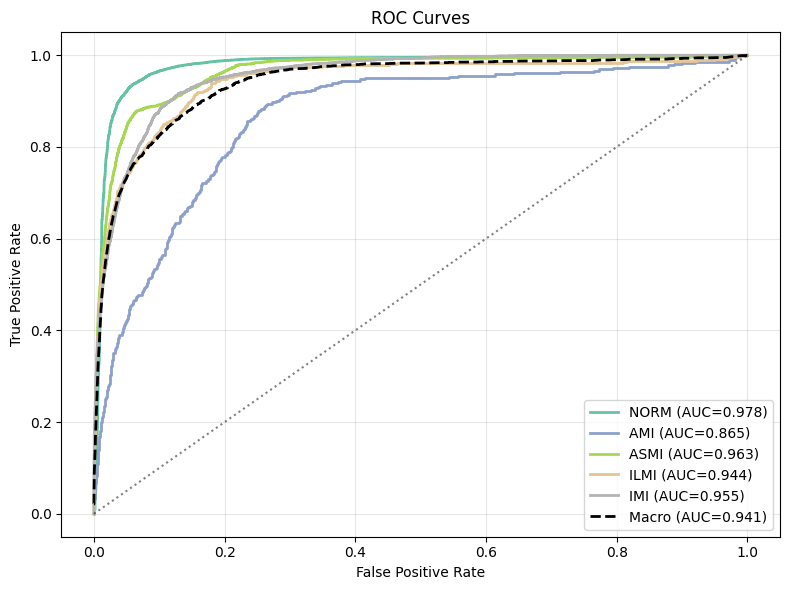


📊 AUC Scores:
   NORM: 0.9779
   AMI: 0.8647
   ASMI: 0.9629
   ILMI: 0.9440
   IMI: 0.9549
   Macro: 0.9409

✅ Saved: roc_curves.png


In [19]:
# === ROC CURVES ===
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))
aucs = []

for i, (class_name, color) in enumerate(zip(TARGET_CLASSES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{class_name} (AUC={roc_auc:.3f})')

# Macro average
all_fpr = np.unique(np.concatenate([roc_curve(y_true_bin[:, i], y_probs[:, i])[0] for i in range(NUM_CLASSES)]))
mean_tpr = np.mean([np.interp(all_fpr, *roc_curve(y_true_bin[:, i], y_probs[:, i])[:2]) for i in range(NUM_CLASSES)], axis=0)
macro_auc = auc(all_fpr, mean_tpr)
ax.plot(all_fpr, mean_tpr, 'k--', lw=2, label=f'Macro (AUC={macro_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k:', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=150)
plt.show()

print(f"\n📊 AUC Scores:")
for class_name, auc_score in zip(TARGET_CLASSES, aucs):
    print(f"   {class_name}: {auc_score:.4f}")
print(f"   Macro: {macro_auc:.4f}")
print("\n✅ Saved: roc_curves.png")

## 14. Save All Results

In [20]:
# === SAVE RESULTS ===
results = {
    'method': 'B - ViT Fine-tuning (TUNED)',
    'model': MODEL_NAME,
    'params': total_params,
    'dataset': {
        'train': len(train_df),
        'val': len(val_df),
        'test': len(test_df)
    },
    'hyperparameters': {
        'batch_size': BATCH_SIZE,
        'epochs_trained': len(history['train_loss']),
        'best_epoch': best_epoch,
        'lr_backbone': LR_BACKBONE,
        'lr_head': LR_HEAD,
        'weight_decay': WEIGHT_DECAY,
        'dropout': DROPOUT_RATE,
        'label_smoothing': LABEL_SMOOTHING,
        'warmup_epochs': WARMUP_EPOCHS,
        'patience': PATIENCE
    },
    'test_results': {
        'accuracy': float(test_acc),
        'f1_weighted': float(test_f1),
        'f1_macro': float(f1_macro),
        'precision': float(precision_weighted),
        'recall': float(recall_weighted),
        'macro_auc': float(macro_auc)
    },
    'per_class': {
        'f1': dict(zip(TARGET_CLASSES, [float(f) for f in f1_per_class])),
        'auc': dict(zip(TARGET_CLASSES, [float(a) for a in aucs]))
    },
    'training_time': str(train_time),
    'final_gap': float(history['train_acc'][-1] - history['val_acc'][-1]) * 100
}

with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f:
    json.dump(results, f, indent=2)
print("✅ Saved: results.json")

# Save history
pd.DataFrame(history).to_csv(os.path.join(OUTPUT_DIR, 'history.csv'), index=False)
print("✅ Saved: history.csv")

# List all files
print(f"\n{'='*50}")
print(f"📁 ALL FILES SAVED TO: {OUTPUT_DIR}")
print(f"{'='*50}")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f"   • {f} ({size:.1f} KB)")

✅ Saved: results.json
✅ Saved: history.csv

📁 ALL FILES SAVED TO: /workspace/output_method_b_tuned
   • best_model.pth (1008023.0 KB)
   • classification_report.txt (0.5 KB)
   • confusion_matrix.png (105.1 KB)
   • history.csv (2.0 KB)
   • per_class_metrics.csv (0.2 KB)
   • results.json (1.1 KB)
   • roc_curves.png (102.9 KB)
   • training_curves.png (178.3 KB)


## 15. Final Summary & Comparison

In [21]:
# === FINAL SUMMARY ===
print(f"\n{'='*70}")
print(f"🎉 METODE B (TUNED) COMPLETE!")
print(f"{'='*70}")

print(f"\n📋 Model: {MODEL_NAME}")
print(f"   Parameters: {total_params:,}")

print(f"\n🔧 Tuned Hyperparameters:")
print(f"   LR Backbone:     {LR_BACKBONE}")
print(f"   LR Head:         {LR_HEAD}")
print(f"   Weight Decay:    {WEIGHT_DECAY}")
print(f"   Dropout:         {DROPOUT_RATE}")
print(f"   Label Smoothing: {LABEL_SMOOTHING}")

print(f"\n📊 Training Summary:")
print(f"   Best Epoch:      {best_epoch}")
print(f"   Training Time:   {train_time}")
final_gap = (history['train_acc'][-1] - history['val_acc'][-1]) * 100
print(f"   Final GAP:       {final_gap:.1f}%", "✅" if final_gap < 5 else "⚠️")

print(f"\n🎯 TEST RESULTS:")
print(f"   Accuracy:      {test_acc*100:.2f}%")
print(f"   F1 Weighted:   {test_f1:.4f}")
print(f"   F1 Macro:      {f1_macro:.4f}")
print(f"   Macro AUC:     {macro_auc:.4f}")

print(f"\n📈 Per-Class F1:")
for c, f in zip(TARGET_CLASSES, f1_per_class):
    bar = '█' * int(f * 30)
    print(f"   {c:6s}: {f:.4f} {bar}")

print(f"\n📁 Output: {OUTPUT_DIR}")
print("="*70)


🎉 METODE B (TUNED) COMPLETE!

📋 Model: google/vit-base-patch16-224
   Parameters: 85,996,805

🔧 Tuned Hyperparameters:
   LR Backbone:     1e-05
   LR Head:         0.0005
   Weight Decay:    0.05
   Dropout:         0.3
   Label Smoothing: 0.1

📊 Training Summary:
   Best Epoch:      13
   Training Time:   1:18:56.430099
   Final GAP:       1.8% ✅

🎯 TEST RESULTS:
   Accuracy:      85.60%
   F1 Weighted:   0.8263
   F1 Macro:      0.5250
   Macro AUC:     0.9409

📈 Per-Class F1:
   NORM  : 0.9466 ████████████████████████████
   AMI   : 0.1055 ███
   ASMI  : 0.7625 ██████████████████████
   ILMI  : 0.5032 ███████████████
   IMI   : 0.3072 █████████

📁 Output: /workspace/output_method_b_tuned


In [22]:
# === COMPARISON TABLE ===
print("\n" + "="*70)
print("📊 COMPARISON: BEFORE vs AFTER TUNING")
print("="*70)
print(f"\n{'Metric':<20} {'Before (Untuned)':<20} {'After (Tuned)':<20}")
print("-"*60)
print(f"{'Best Epoch':<20} {'17':<20} {f'{best_epoch}':<20}")
print(f"{'Train Acc (final)':<20} {'100.00%':<20} {f'{history["train_acc"][-1]*100:.2f}%':<20}")
print(f"{'Val Acc (best)':<20} {'90.16%':<20} {f'{max(history["val_acc"])*100:.2f}%':<20}")
print(f"{'GAP':<20} {'~10%':<20} {f'{final_gap:.1f}%':<20}")
print(f"{'Val Loss trend':<20} {'↗️ Naik (bad)':<20} {'Check curve':<20}")
print(f"{'Test Accuracy':<20} {'89.80%':<20} {f'{test_acc*100:.2f}%':<20}")
print(f"{'Test F1 Macro':<20} {'0.6371':<20} {f'{f1_macro:.4f}':<20}")
print("-"*60)
print("\n💡 Key Improvements:")
print("   1. GAP should be smaller (less overfitting)")
print("   2. Val Loss should be more stable")
print("   3. F1 Macro should improve (better on minority classes)")

SyntaxError: f-string: unterminated string (2015716403.py, line 8)